# RF-DETR Chess Inference Demo

This notebook loads `rfdetr-chess-model.pth`, runs inference on one test image, and visualizes detections using Matplotlib.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from PIL import Image

from rfdetr import RFDETRSmall

repo_root = Path.cwd()
model_path = repo_root / "rfdetr-chess-model.pth"
image_path = repo_root / "test-images" / "test-13.jpeg"
device = "cuda" if torch.cuda.is_available() else "cpu"
threshold = 0.35

print(f"Model path: {model_path}")
print(f"Image path: {image_path}")
print(f"Device: {device}")

Model path: c:\Users\sirom\Desktop\vision-ws\rf-detr-demo\Dynamic-Chess-Board-Piece-Extraction\rfdetr-chess-model.pth
Image path: c:\Users\sirom\Desktop\vision-ws\rf-detr-demo\Dynamic-Chess-Board-Piece-Extraction\test-images\test-13.jpeg
Device: cuda


In [8]:
assert model_path.is_file(), f"Model file not found: {model_path}"
assert image_path.is_file(), f"Test image not found: {image_path}"

checkpoint = torch.load(str(model_path), map_location="cpu", weights_only=False)
args = checkpoint.get("args")
if isinstance(args, dict):
    class_names = list(args.get("class_names") or [])
else:
    class_names = list(getattr(args, "class_names", None) or [])

assert class_names, "class_names are missing in checkpoint args"
num_classes = len(class_names)

model = RFDETRSmall(
    device=device,
    pretrain_weights=str(model_path.resolve()),
    num_classes=num_classes,
)

detections = model.predict(str(image_path), threshold=threshold, include_source_image=True)
source_image = detections.metadata.get("source_image") if detections.metadata else None
if source_image is None:
    image_np = np.array(Image.open(image_path).convert("RGB"))
else:
    image_np = np.asarray(source_image)

print(f"Image array type: {type(image_np)}, Shape: {image_np.shape}")
print(f"Detections count: {len(detections)}")

[2026-05-05 13:35:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-05 13:35:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-05 13:35:52] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Image array type: <class 'numpy.ndarray'>, Shape: (1600, 1200, 3)
Detections count: 30


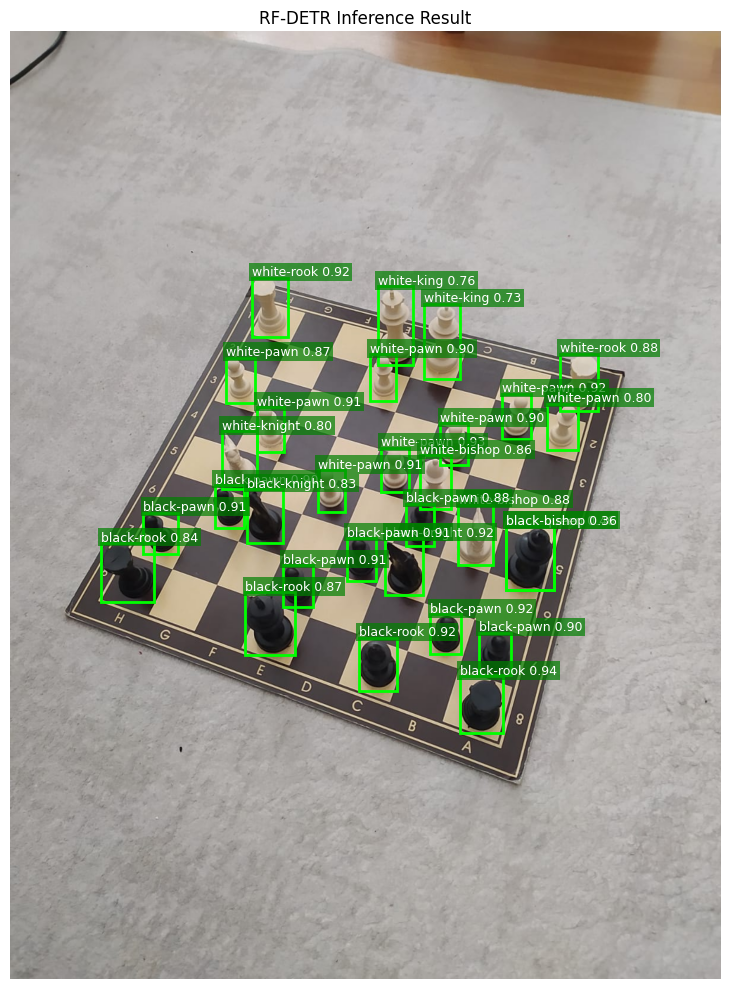

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_np)

if len(detections):
    for xyxy, class_id, conf in zip(detections.xyxy, detections.class_id, detections.confidence):
        x1, y1, x2, y2 = xyxy
        width = x2 - x1
        height = y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            width,
            height,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

        label_name = class_names[int(class_id)] if 0 <= int(class_id) < len(class_names) else str(int(class_id))
        ax.text(
            x1,
            max(0, y1 - 4),
            f"{label_name} {float(conf):.2f}",
            fontsize=9,
            color="white",
            bbox={"facecolor": "green", "alpha": 0.7, "edgecolor": "none", "pad": 2},
        )

ax.set_title("RF-DETR Inference Result")
ax.axis("off")
plt.tight_layout()
plt.show()